# WDM MUX -- Cascaded MZI Lattice Filter (Analytic SAX Model)

This notebook builds a purely **analytic** (no meep, no FDTD) `sax` circuit model of a
cascaded Mach-Zehnder lattice filter -- the classical architecture behind CWDM
(de)multiplexers, e.g. Luceda's
[`mux2` tutorial](https://academy.lucedaphotonics.com/training/topical_training/wdm_transmitter_mzi/mux2).
`N` ideal directional couplers are joined by `N-1` delay-arm pairs, all sharing one
`delta_L_um`; the goal here is to compare **2 vs. 4 couplers** and show, quantitatively,
that more couplers widen the flat-top passband.

A real FDTD-characterized comparison (using `pic_toolkit.models.mzi`'s cached
S-parameters instead of the ideal analytic couplers below) is deferred to a later
notebook -- this one is theory only, and is the first place in this repo that actually
calls `sax.circuit()` (every other `pic_toolkit.models` module only produces
SAX-*shaped* data by hand). The reusable building blocks live in
`pic_toolkit.circuits.mzi_lattice`.

**Do not use "Run All."**


## 1. Design parameters

Each lattice stage's phase depends on the round-trip phase difference between its two
arms,
$$\phi(\lambda) = \frac{2\pi\, n_{\mathrm{eff}}(\lambda)\, \Delta L}{\lambda},$$
and the filter repeats with a free spectral range set by
$$\Delta L = \frac{\lambda_0^2}{n_g \cdot \mathrm{FSR}}$$
(the same relation `07_mzi.ipynb` Section 10-11 already fits from measured fringe
spacing).

Rather than target FSR directly, `delta_L_um=15.0` is chosen **first**, to land exactly
on `07_mzi.ipynb`'s own already-simulated `delta_L_um` sweep point
(`data/sparams/mzi/sweep/mzi_deltaL15.0.json`) -- so a later FDTD-based comparison can
reuse that existing run rather than needing a new one. `wl0_um`, `n_eff0`, and `n_g0`
are pulled from that same notebook's own cached Section 10-11 output at `1.35um`:
`n_eff0=2.4085` (phase index, from MPB arm dispersion) and `n_g0=2.763` (group index,
from the FDTD S21 fringe-spacing fit -- not the MPB-dispersion group-index estimate,
`~2.928`, which characterizes only a straight arm segment rather than the full
round-trip through both couplers' S-bends).


In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pic_toolkit import style
from pic_toolkit.circuits import mzi_lattice as ml

style.apply_style()
%matplotlib inline

# ============================================================
# USER PARAMETERS
# ============================================================
WL0_UM = 1.35        # design center wavelength -- matches this toolkit's convention
                      # (waveguide.yaml/07_mzi.ipynb are both characterized at 1.35um)
N_EFF0 = 2.4085       # phase index at WL0_UM, from 07_mzi.ipynb's MPB arm dispersion
N_G0 = 2.763          # group index at WL0_UM, from 07_mzi.ipynb's FDTD FSR-fit (Section 10)
DELTA_L_UM = 15.0     # design target -- matches 07_mzi.ipynb's own delta_L sweep point

fsr_nm = ml.delta_L_um_to_fsr(DELTA_L_UM, WL0_UM, N_G0) * 1000
print(f"delta_L_um = {DELTA_L_UM} -> FSR = {fsr_nm:.2f} nm (target was ~40nm)")


delta_L_um = 15.0 -> FSR = 43.97 nm (target was ~40nm)


/home/yuma/miniconda3/envs/mp/lib/python3.10/site-packages/sax/backends/__init__.py:78: UserWarning: klujax not found. Please install klujax for better performance during circuit evaluation!
  warnings.warn(


## 2. Ideal building blocks

Every coupler is an ideal, lossless 2x2 splitter with power-coupling ratio $\kappa$:
$$
\begin{pmatrix}E_{\text{out,top}}\\E_{\text{out,bot}}\end{pmatrix} =
\begin{pmatrix}\sqrt{1-\kappa} & i\,\mathrm{sign}\sqrt{\kappa}\\
i\,\mathrm{sign}\sqrt{\kappa} & \sqrt{1-\kappa}\end{pmatrix}
\begin{pmatrix}E_{\text{in,top}}\\E_{\text{in,bot}}\end{pmatrix},
$$
the standard $\pm90^\circ$ cross-port phase a lossless 3dB-style coupler must carry to
stay unitary (`sign=+1` unless a specific stage's synthesis needs `-1` -- see Section 4).

Every arm is an ideal phase delay, $S_{21}=\exp\!\left(i\,\phi(\lambda)\cdot
\frac{\text{length}}{\Delta L}\right)$ using $\phi(\lambda)$ from Section 1 (only the
*difference* in length between a stage's two arms matters for this lossless model, so
one arm is fixed at length 0 and the other at `delta_L_um`).

Sanity check below: at one sample wavelength, every port's outgoing power must sum to 1
(lossless/unitary).


In [2]:
coupler = ml.ideal_coupler_model(kappa=0.5, sign=1)
arm = ml.ideal_arm_model(length_um=DELTA_L_UM, n_eff0=N_EFF0, n_g0=N_G0, wl0_um=WL0_UM)

S_coupler = coupler(wl=WL0_UM)
S_arm = arm(wl=WL0_UM)
power_out_top = abs(S_coupler[("in_top", "out_top")]) ** 2 + abs(S_coupler[("in_top", "out_bot")]) ** 2
print(f"coupler: power out of in_top = {power_out_top:.6f} (should be 1.0)")
print(f"arm: |S21|^2 = {abs(S_arm[('in', 'out')]) ** 2:.6f} (should be 1.0)")


coupler: power out of in_top = 1.000000 (should be 1.0)
arm: |S21|^2 = 1.000000 (should be 1.0)


## 3. N=2 -- the ordinary single MZI (baseline)

Two 50:50 couplers joined by one delay arm is just the plain MZI `07_mzi.ipynb` already
built in FDTD -- $\kappa=[0.5, 0.5]$, no synthesis needed. Its transmission is a plain
sinusoid in wavelength, with **no flat region** anywhere: this is the baseline the N=4
lattice below is compared against.


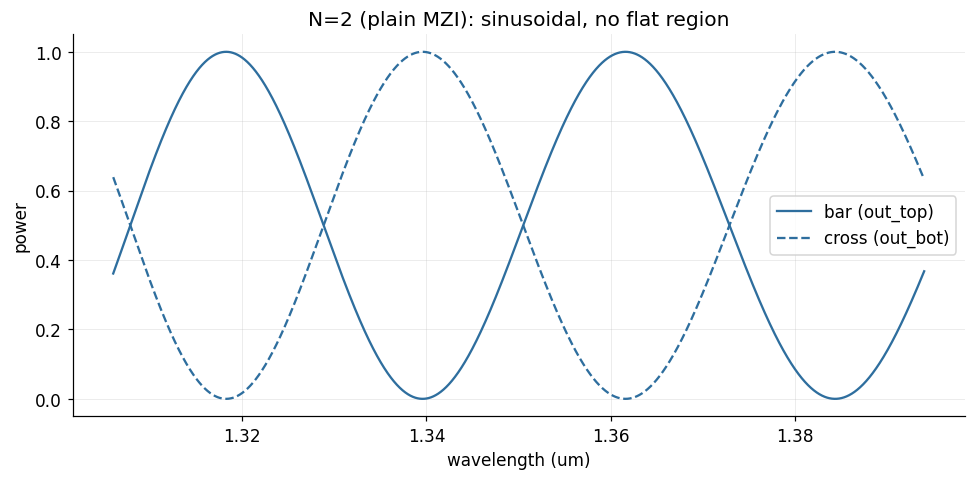

unitarity check: max|bar+cross-1| = 3.58e-07


In [3]:
fsr_um = ml.delta_L_um_to_fsr(DELTA_L_UM, WL0_UM, N_G0)
wl_sweep = jnp.linspace(WL0_UM - fsr_um, WL0_UM + fsr_um, 4000)  # ~2 FSR span

kappas_2, signs_2 = [0.5, 0.5], [1, 1]
circuit_2, _ = ml.build_lattice_circuit(kappas_2, signs_2, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)
S_2 = circuit_2(wl=wl_sweep)
bar_2 = np.abs(np.asarray(S_2[("in_top", "out_top")])) ** 2
cross_2 = np.abs(np.asarray(S_2[("in_top", "out_bot")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wl_sweep, bar_2, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(wl_sweep, cross_2, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("N=2 (plain MZI): sinusoidal, no flat region")
ax.legend()
fig.tight_layout()
plt.show()

print(f"unitarity check: max|bar+cross-1| = {np.max(np.abs(bar_2 + cross_2 - 1)):.2e}")


## 4. N=4 -- synthesized maximally-flat (halfband) lattice

Widening the passband (not just being flat at one point) is a **halfband filter**
design target: the bar-port power
$$|A(\phi)|^2 = P_K\!\left(\sin^2\frac{\phi}{2}\right), \qquad
P_K(x)=\sum_{k=K}^{2K-1}\binom{2K-1}{k}x^k(1-x)^{2K-1-k}, \qquad N=2K$$
is flat (many vanishing derivatives) at **both** $\phi=0$ and $\phi=\pi$ while always
crossing exactly 0.5 at $\phi=\pi/2$, regardless of $K$ -- so every order shares the
same -3dB crossover, and only the near-flat-top region widens as $K$ (i.e. $N$) grows.
For $N=4$ ($K=2$), $P_2(x)=3x^2-2x^3$ (the familiar cubic "smoothstep").

The physical coupling ratios $\kappa_i$ that realize this in a real lattice are found
by a classical two-port "layer-peeling" synthesis (spectral-factor the target into a
lossless paraunitary pair, then recursively strip one coupler at a time) --
`synthesize_maximally_flat_kappas` implements this and verifies its own output by
reconstructing the target response from the returned $\kappa_i$ before returning them.


kappa_i: [0.9328 0.     0.7503 0.5006]
sign_i:  [1, 1, 1, -1]  (the coupler's cross-port phase convention -- see Section 2)


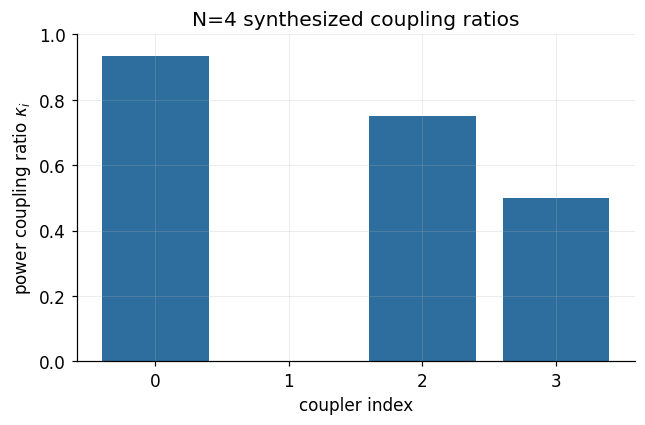

In [4]:
kappas_4, signs_4 = ml.synthesize_maximally_flat_kappas(4)
print("kappa_i:", np.round(kappas_4, 4))
print("sign_i: ", signs_4, " (the coupler's cross-port phase convention -- see Section 2)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(kappas_4)), kappas_4, color=style.COLOR_STEEL)
ax.set_xlabel("coupler index")
ax.set_ylabel(r"power coupling ratio $\kappa_i$")
ax.set_xticks(range(len(kappas_4)))
ax.set_ylim(0, 1)
ax.set_title("N=4 synthesized coupling ratios")
fig.tight_layout()
plt.show()


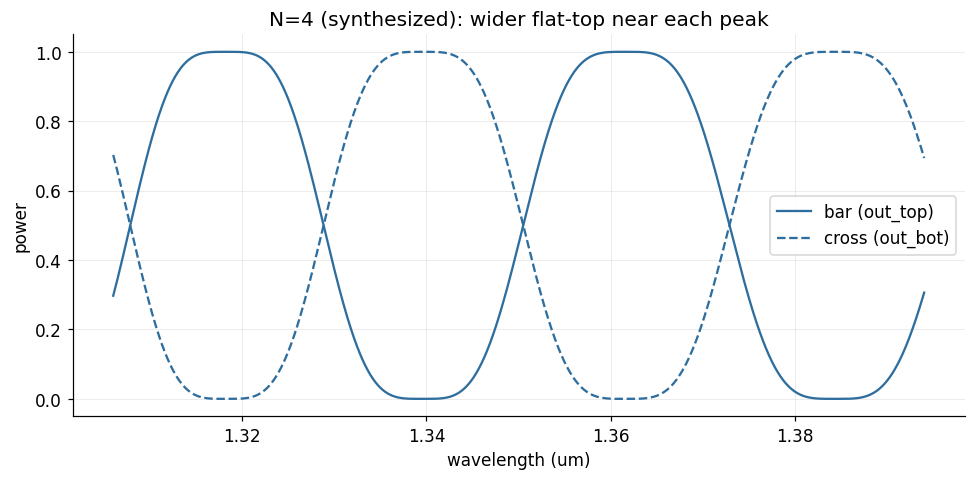

unitarity check: max|bar+cross-1| = 5.36e-07


In [5]:
circuit_4, _ = ml.build_lattice_circuit(kappas_4, signs_4, DELTA_L_UM, N_EFF0, N_G0, WL0_UM)
S_4 = circuit_4(wl=wl_sweep)
bar_4 = np.abs(np.asarray(S_4[("in_top", "out_top")])) ** 2
cross_4 = np.abs(np.asarray(S_4[("in_top", "out_bot")])) ** 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wl_sweep, bar_4, color=style.COLOR_STEEL, label="bar (out_top)")
ax.plot(wl_sweep, cross_4, color=style.COLOR_STEEL, ls="--", label="cross (out_bot)")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("N=4 (synthesized): wider flat-top near each peak")
ax.legend()
fig.tight_layout()
plt.show()

print(f"unitarity check: max|bar+cross-1| = {np.max(np.abs(bar_4 + cross_4 - 1)):.2e}")


## 5. Comparison: does N=4 actually flatten the passband?

Overlay both bar-port curves near one channel peak, and measure the -1dB bandwidth (how
much of the FSR stays within 1dB of the peak) and the -3dB bandwidth (the channel-edge
crossover, which the halfband construction keeps fixed at the same fraction of FSR for
every N by design -- a useful check that the synthesis is behaving as intended).


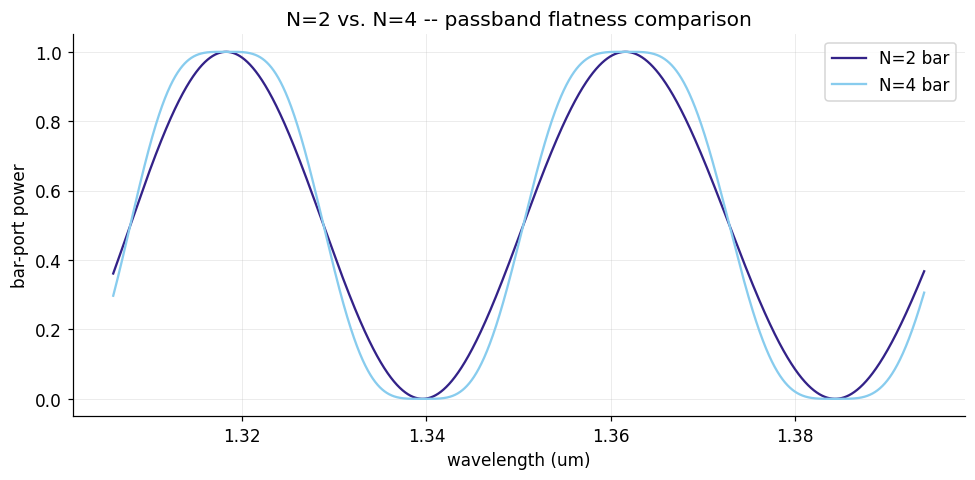

N=2: -1dB width = 13.39 nm (30.5% of FSR), -3dB width = 22.30 nm (50.7% of FSR)
N=4: -1dB width = 15.22 nm (34.6% of FSR), -3dB width = 20.91 nm (47.6% of FSR)


In [6]:
def db_bandwidth(wl, bar, db):
    """Contiguous width (nm), around the peak, where bar power stays within `db` of the peak."""
    thresh = 10 ** (-db / 10) * bar.max()
    above = bar > thresh
    i0 = int(np.argmax(bar))
    lo = i0
    while lo > 0 and above[lo - 1]:
        lo -= 1
    hi = i0
    while hi < len(above) - 1 and above[hi + 1]:
        hi += 1
    return (wl[hi] - wl[lo]) * 1000  # nm


wl_np = np.asarray(wl_sweep)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wl_np, bar_2, color=style.COLOR_CYCLE[0], label="N=2 bar")
ax.plot(wl_np, bar_4, color=style.COLOR_CYCLE[1], label="N=4 bar")
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("bar-port power")
ax.set_title("N=2 vs. N=4 -- passband flatness comparison")
ax.legend()
fig.tight_layout()
plt.show()

fsr_nm_ = fsr_um * 1000
for label, bar in (("N=2", bar_2), ("N=4", bar_4)):
    w1 = db_bandwidth(wl_np, bar, 1)
    w3 = db_bandwidth(wl_np, bar, 3)
    print(f"{label}: -1dB width = {w1:5.2f} nm ({100 * w1 / fsr_nm_:4.1f}% of FSR), "
          f"-3dB width = {w3:5.2f} nm ({100 * w3 / fsr_nm_:4.1f}% of FSR)")


---

## Where this could go next (not built here)

This notebook is theory only -- ideal, lossless, dispersion-corrected-but-otherwise
perfect couplers and arms. Natural next steps, deferred per the current request:

- **FDTD-based comparison**: rebuild the same lattice using `pic_toolkit.models.mzi`'s
  cached, FDTD-measured S-parameters (real magnitude *and* phase, unlike
  `models/coupler.py`'s power-only model) in place of `ideal_coupler_model`/
  `ideal_arm_model`, and compare against the analytic curves above.
- **Luceda's published 5-coupler design** (`[0.5, 0.13, 0.12, 0.5, 0.25]`, from *"Coarse
  Wavelength Division Multiplexer on Silicon-on-Insulator for 100GbE"`) uses per-stage
  *non-uniform* `delta_L` to correct for a real, dispersive coupler's phase error -- out
  of scope for this notebook's uniform-`delta_L`, ideal-coupler model.
- A `data/design_points/`-style saved artifact, once validated against FDTD.
